# TFT — Multiple Series (Capstone, completed)

The completed version, with the extra cells added during the lecture.

A Temporal Fusion Transformer trained across many electricity load series at once, with static, past
and future covariates.

| | |
|---|---|
| **Course section** | Capstone Project: Multiple Series with TFT |
| **Data** | `electricity.csv`, `electricity-future.csv`, `best_params.csv` |
| **Libraries** | `darts` (`TFTModel`), `torch` |
| **Runs on** | GPU strongly recommended |
| **Briefing** | `Project Briefing Temporal Fusion Transformer (TFT) for Time Series Forecasting.pdf` |

> **Turn the GPU on before you run this.** In Colab: `Runtime → Change runtime type → T4 GPU`.
> On CPU these cells finish eventually, but not in a sitting.

> **Version note.** This section pins `darts==0.36.0`, while the other Darts sections pin `0.45.0`.
> If a cell fails on an unexpected keyword argument, that is why. Install from the `requirements.txt`
> in this folder.

## Roadmap

1. Libraries and data
2. Build the target series with time and static covariates
3. Past covariates
4. Future covariates
5. Scaling
6. Fit the TFT
7. Cross-validation
8. Parameter tuning
9. Predict the future

## Static covariates are the point

With one series, static covariates do nothing — a constant column carries no information. With many
series they become the mechanism that lets one shared model behave differently for each one. That is
the idea this capstone is testing.

---

Part of **[Master Time Series Analysis and Forecasting with Python](https://www.udemy.com/course/forecasting-python/?referralCode=63045C9CC807EB1EBD9A)** · [All notebooks](https://github.com/diogoalvesderesende/time-series-forecasting-python)

# Libraries and Data

In [1]:
# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Path to the folder
%cd /content/drive/MyDrive/Python - Time Series Forecasting/Deep Learning for Time Series Forecasting/CAPSTONE PROJECT - TFT for multiple series

/content/drive/MyDrive/Python - Time Series Forecasting/Deep Learning for Time Series Forecasting/CAPSTONE PROJECT - TFT for multiple series


In [3]:
# Install darts library
!pip install -q "darts[torch]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.7/67.7 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.2/412.2 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.8/815.8 kB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 62.5 MB/s eta 0:00:00


In [8]:
# Standard Libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
from sklearn.model_selection import ParameterGrid

# Darts functions
from darts.timeseries import TimeSeries
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.dataprocessing.transformers import Scaler
from darts.models import TFTModel

In [9]:
# Loading the Data and Setting the Index
# Hourly electricity consumption data
df = pd.read_csv("electricity.csv", index_col = "ds", parse_dates = True)
df.head()

,unique_id,y,Exogenous1,Exogenous2
ds,,,,
2016-10-22 00:00:00,BE,70.00,49593.0,57253.0
2016-10-22 01:00:00,BE,37.10,46073.0,51887.0
2016-10-22 02:00:00,BE,37.10,44927.0,51896.0
2016-10-22 03:00:00,BE,44.75,44483.0,48428.0
2016-10-22 04:00:00,BE,37.10,44338.0,46721.0


In [10]:
# Count the number of occurrences of each unique ID in the dataframe
df.unique_id.value_counts()

,count
unique_id,
BE,1680
DE,1680
FR,1680
NP,1680
PJM,1680


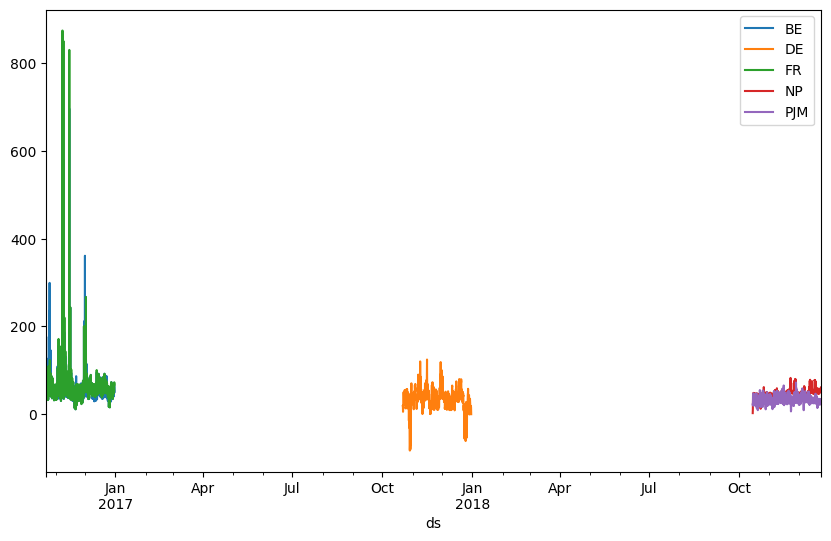

In [11]:
# Visualize the data for each unique ids
# we can see that the date range are not equal
# 3 groups - (BE, FR), DE, (NP, PJM)
plt.rcParams["figure.figsize"] = (10,6)
for id in df['unique_id'].unique():
  df[df['unique_id'] == id]['y'].plot(label=id)

plt.legend();

Pick unique_id `BE` and `FR` for the modelling

In [12]:
# Filter the dataframe to include only rows where the 'unique_id' is "FR" or "BE"
df = df[df['unique_id'].isin(['FR', 'BE'])]
df.head()

,unique_id,y,Exogenous1,Exogenous2
ds,,,,
2016-10-22 00:00:00,BE,70.00,49593.0,57253.0
2016-10-22 01:00:00,BE,37.10,46073.0,51887.0
2016-10-22 02:00:00,BE,37.10,44927.0,51896.0
2016-10-22 03:00:00,BE,44.75,44483.0,48428.0
2016-10-22 04:00:00,BE,37.10,44338.0,46721.0


In [13]:
# Information about the df
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3360 entries, 2016-10-22 00:00:00 to 2016-12-30 23:00:00
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   unique_id   3360 non-null   object 
 1   y           3360 non-null   float64
 2   Exogenous1  3360 non-null   float64
 3   Exogenous2  3360 non-null   float64
dtypes: float64(3), object(1)
memory usage: 131.2+ KB


# Time Series, Time and Static Covariates

In [22]:
# Target series, static covariates and time features
COUNTRIES = ["BE", "FR"]

MODEL_DF = df.reset_index().copy()
MODEL_DF["SERIES_ID"] = MODEL_DF["unique_id"].map({"BE": 0, "FR": 1})
MODEL_DF = MODEL_DF.sort_values(["SERIES_ID", "ds"])

SERIES = TimeSeries.from_group_dataframe(
    MODEL_DF,
    group_cols="SERIES_ID",
    time_col="ds",
    value_cols="y",
    freq="h"
)

for INDEX, COUNTRY in enumerate(COUNTRIES):
  print(COUNTRY, SERIES[INDEX].start_time(), SERIES[INDEX].end_time())
  print(SERIES[INDEX].static_covariates)

# THE CUSTOM YEAR FEATURE ALREADY EXISTS IN THE ORIGINAL NOTEBOOK STRUCTURE
def ENCODE_YEAR(INDEX):
  return (INDEX.year - 2000) / 50

ADD_ENCODERS = {
    "cyclic": {"future": ["hour", "dayofweek", "month"]},
    "datetime_attribute": {"future": ["day", "week"]},
    "position": {"past": ["relative"], "future": ["relative"]},
    "custom": {"past": [ENCODE_YEAR], "future": [ENCODE_YEAR]},
    "transformer": Scaler()
}

BE 2016-10-22 00:00:00 2016-12-30 23:00:00
static_covariates  SERIES_ID
y                        0.0
FR 2016-10-22 00:00:00 2016-12-30 23:00:00
static_covariates  SERIES_ID
y                        1.0


# Past Covariates

In [15]:
# Past covariates
PAST_COVARIATES = TimeSeries.from_group_dataframe(
    MODEL_DF,
    group_cols="SERIES_ID",
    time_col="ds",
    value_cols=["Exogenous1", "Exogenous2"],
    freq="h"
)

PAST_COVARIATES

[                     Exogenous1  Exogenous2
 ds                                         
 2016-10-22 00:00:00     49593.0     57253.0
 2016-10-22 01:00:00     46073.0     51887.0
 2016-10-22 02:00:00     44927.0     51896.0
 2016-10-22 03:00:00     44483.0     48428.0
 2016-10-22 04:00:00     44338.0     46721.0
 ...                         ...         ...
 2016-12-30 19:00:00     70329.0     75911.0
 2016-12-30 20:00:00     69121.0     73706.0
 2016-12-30 21:00:00     66647.0     71003.0
 2016-12-30 22:00:00     65886.0     68330.0
 2016-12-30 23:00:00     66846.0     72259.0
 
 shape: (1680, 2, 1), freq: h, size: 26.25 KB
 
 Static covariates:
     static_covariates  SERIES_ID
     global_components        0.0,
                      Exogenous1  Exogenous2
 ds                                         
 2016-10-22 00:00:00     49593.0     57253.0
 2016-10-22 01:00:00     46073.0     51887.0
 2016-10-22 02:00:00     44927.0     51896.0
 2016-10-22 03:00:00     44483.0     48428.0
 2016-

# Future Covariates

In [16]:
# Future covariates
FUTURE_DF = pd.read_csv("electricity-future.csv", parse_dates=["ds"])
FUTURE_DF = FUTURE_DF[FUTURE_DF["unique_id"].isin(COUNTRIES)].copy()
FUTURE_DF["SERIES_ID"] = FUTURE_DF["unique_id"].map({"BE": 0, "FR": 1})

FUTURE_MODEL_DF = pd.concat(
    [
        MODEL_DF[["ds", "SERIES_ID", "Exogenous1", "Exogenous2"]],
        FUTURE_DF[["ds", "SERIES_ID", "Exogenous1", "Exogenous2"]]
    ],
    ignore_index=True
)

FUTURE_MODEL_DF = FUTURE_MODEL_DF.drop_duplicates(
    subset=["SERIES_ID", "ds"],
    keep="last"
).sort_values(["SERIES_ID", "ds"])

FUTURE_COVARIATES = TimeSeries.from_group_dataframe(
    FUTURE_MODEL_DF,
    group_cols="SERIES_ID",
    time_col="ds",
    value_cols=["Exogenous1", "Exogenous2"],
    freq="h"
)

for INDEX, COUNTRY in enumerate(COUNTRIES):
  print(COUNTRY, FUTURE_COVARIATES[INDEX].end_time())

BE 2016-12-31 23:00:00
FR 2016-12-31 23:00:00


# Scaling

In [17]:
# Import the Scaler class and initialize two instances of it
scaler1 = Scaler()
scaler2 = Scaler()

In [23]:
# Apply the scaler to the time series
y_transformed = scaler1.fit_transform(SERIES)

In [24]:
# Scaling the past covariates
past_covariates_transformed = scaler2.fit_transform(PAST_COVARIATES)
past_covariates_transformed

[                     Exogenous1  Exogenous2
 ds                                         
 2016-10-22 00:00:00    0.221503    0.392919
 2016-10-22 01:00:00    0.097011    0.262803
 2016-10-22 02:00:00    0.056481    0.263021
 2016-10-22 03:00:00    0.040778    0.178928
 2016-10-22 04:00:00    0.035650    0.137536
 ...                         ...         ...
 2016-12-30 19:00:00    0.954872    0.845344
 2016-12-30 20:00:00    0.912149    0.791877
 2016-12-30 21:00:00    0.824651    0.726334
 2016-12-30 22:00:00    0.797737    0.661518
 2016-12-30 23:00:00    0.831689    0.756790
 
 shape: (1680, 2, 1), freq: h, size: 26.25 KB
 
 Static covariates:
     static_covariates  SERIES_ID
     global_components        0.0,
                      Exogenous1  Exogenous2
 ds                                         
 2016-10-22 00:00:00    0.221503    0.392919
 2016-10-22 01:00:00    0.097011    0.262803
 2016-10-22 02:00:00    0.056481    0.263021
 2016-10-22 03:00:00    0.040778    0.178928
 2016-

In [25]:
# Scaling the future covariates
future_covariates_transformed = scaler2.transform(FUTURE_COVARIATES)
future_covariates_transformed

[                     Exogenous1  Exogenous2
 ds                                         
 2016-10-22 00:00:00    0.221503    0.392919
 2016-10-22 01:00:00    0.097011    0.262803
 2016-10-22 02:00:00    0.056481    0.263021
 2016-10-22 03:00:00    0.040778    0.178928
 2016-10-22 04:00:00    0.035650    0.137536
 ...                         ...         ...
 2016-12-31 19:00:00    0.954872    0.797963
 2016-12-31 20:00:00    0.912149    0.763700
 2016-12-31 21:00:00    0.824651    0.688700
 2016-12-31 22:00:00    0.797737    0.649224
 2016-12-31 23:00:00    0.831689    0.771751
 
 shape: (1704, 2, 1), freq: h, size: 26.62 KB
 
 Static covariates:
     static_covariates  SERIES_ID
     global_components        0.0,
                      Exogenous1  Exogenous2
 ds                                         
 2016-10-22 00:00:00    0.221503    0.392919
 2016-10-22 01:00:00    0.097011    0.262803
 2016-10-22 02:00:00    0.056481    0.263021
 2016-10-22 03:00:00    0.040778    0.178928
 2016-

# TFT Model

In [26]:
# Forecasting horizon
FORECASTING_HORIZON = 24

In [27]:
# Base TFT model
MODEL = TFTModel(
    input_chunk_length=96,
    output_chunk_length=FORECASTING_HORIZON,
    hidden_size=16,
    lstm_layers=2,
    num_attention_heads=4,
    dropout=0.1,
    batch_size=64,
    n_epochs=10,
    use_static_covariates=True,
    add_encoders=ADD_ENCODERS,
    pl_trainer_kwargs={"accelerator": "gpu", "devices": [0]}
)

MODEL.fit(
    y_transformed,
    past_covariates=past_covariates_transformed,
    future_covariates=future_covariates_transformed
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                              ┃ Type                             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ train_metrics                     │ MetricCollection                 │      0 │ train │     0 │
│ 1  │ val_metrics                       │ MetricCollection                 │      0 │ train │     0 │
│ 2  │ input_embeddings                  │ _MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ static_covariates_vsn             │ _VariableSelectionNetwork        │    528 │ train │     0 │
│ 4  │ encoder_vsn                       │ _VariableSelectionNetwork        │ 12.4 K │ train │     0 │
│ 5  │ decoder_vsn                       │ _VariableSelectionNetwork        │  8.2 K │ train │     0 │
│ 6  │ static_context_grn                │ _GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 7  │ static_context_hidden_encoder_grn │ _GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_cell_encoder_grn   │ _GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_enrichment         │ _GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ lstm_encoder                      │ LSTM                             │  4.4 K │ train │     0 │
│ 11 │ lstm_decoder                      │ LSTM                             │  4.4 K │ train │     0 │
│ 12 │ post_lstm_gan                     │ _GateAddNorm                     │    576 │ train │     0 │
│ 13 │ static_enrichment_grn             │ _GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 14 │ multihead_attn                    │ _InterpretableMultiHeadAttention │    676 │ train │     0 │
│ 15 │ post_attn_gan                     │ _GateAddNorm                     │    576 │ train │     0 │
│ 16 │ feed_forward_block                │ _GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 17 │ pre_output_gan                    │ _GateAddNorm                     │    576 │ train │     0 │
│ 18 │ output_layer                      │ Linear                           │    289 │ train │     0 │
└────┴───────────────────────────────────┴──────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 39.3 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 39.3 K                                                                                               
Total estimated model params size (MB): 0.314                                                                      
Modules in train mode: 581                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/data.py:106: Total length of `list` across 
ranks is zero. Please make sure this was your intention.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


TFTModel(output_chunk_shift=0, hidden_size=16, lstm_layers=2, num_attention_heads=4, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.1, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=False, skip_interpolation=False, loss_fn=None, likelihood=None, norm_type=LayerNorm, use_static_covariates=True, input_chunk_length=96, output_chunk_length=24, batch_size=64, n_epochs=10, add_encoders={'cyclic': {'future': ['hour', 'dayofweek', 'month']}, 'datetime_attribute': {'future': ['day', 'week']}, 'position': {'past': ['relative'], 'future': ['relative']}, 'custom': {'past': [<function ENCODE_YEAR at 0x7cc78e793a60>], 'future': [<function ENCODE_YEAR at 0x7cc78e793a60>]}, 'transformer': Scaler}, pl_trainer_kwargs={'accelerator': 'gpu', 'devices': [0]})

# Cross Validation

In [28]:
# Rolling cross-validation
CV = MODEL.historical_forecasts(
    series=y_transformed,
    past_covariates=past_covariates_transformed,
    future_covariates=future_covariates_transformed,
    start=0.85,
    forecast_horizon=FORECASTING_HORIZON,
    stride=24,
    retrain=True,
    last_points_only=False
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                              ┃ Type                             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ train_metrics                     │ MetricCollection                 │      0 │ train │     0 │
│ 1  │ val_metrics                       │ MetricCollection                 │      0 │ train │     0 │
│ 2  │ input_embeddings                  │ _MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ static_covariates_vsn             │ _VariableSelectionNetwork        │    528 │ train │     0 │
│ 4  │ encoder_vsn                       │ _VariableSelectionNetwork        │ 12.4 K │ train │     0 │
│ 5  │ decoder_vsn                       │ _VariableSelectionNetwork        │  8.2 K │ train │     0 │
│ 6  │ static_context_grn                │ _GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 7  │ static_context_hidden_encoder_grn │ _GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_cell_encoder_grn   │ _GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_enrichment         │ _GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ lstm_encoder                      │ LSTM                             │  4.4 K │ train │     0 │
│ 11 │ lstm_decoder                      │ LSTM                             │  4.4 K │ train │     0 │
│ 12 │ post_lstm_gan                     │ _GateAddNorm                     │    576 │ train │     0 │
│ 13 │ static_enrichment_grn             │ _GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 14 │ multihead_attn                    │ _InterpretableMultiHeadAttention │    676 │ train │     0 │
│ 15 │ post_attn_gan                     │ _GateAddNorm                     │    576 │ train │     0 │
│ 16 │ feed_forward_block                │ _GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 17 │ pre_output_gan                    │ _GateAddNorm                     │    576 │ train │     0 │
│ 18 │ output_layer                      │ Linear                           │    289 │ train │     0 │
└────┴───────────────────────────────────┴──────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 39.3 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 39.3 K                                                                                               
Total estimated model params size (MB): 0.314                                                                      
Modules in train mode: 581                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

...

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/data.py:106: Total length of `list` across 
ranks is zero. Please make sure this was your intention.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


In [ ]:
# Cross-validation metrics in the original scale
CV_ORIGINAL = y_transformed.inverse_transform(CV)
CV_RESULTS = []

for SERIES_INDEX, COUNTRY in enumerate(COUNTRIES):
  COUNTRY_RMSE = []
  COUNTRY_MAE = []

  for FORECAST in CV_ORIGINAL[SERIES_INDEX]:
    ACTUAL = SERIES[SERIES_INDEX].slice_intersect(FORECAST)
    COUNTRY_RMSE.append(
        np.sqrt(mean_squared_error(ACTUAL.values(), FORECAST.values()))
    )
    COUNTRY_MAE.append(
        mean_absolute_error(ACTUAL.values(), FORECAST.values())
    )

  CV_RESULTS.append({
      "unique_id": COUNTRY,
      "rmse": np.mean(COUNTRY_RMSE),
      "mae": np.mean(COUNTRY_MAE)
  })

CV_RESULTS_DF = pd.DataFrame(CV_RESULTS)
CV_RESULTS_DF

# Parameter Tuning

In [ ]:
from sklearn.model_selection import ParameterSampler

In [ ]:
# Parameter grid
PARAM_GRID = {
    "input_chunk_length": [48, 96, 168],
    "output_chunk_length": [24],
    "hidden_size": [8, 16, 24],
    "num_attention_heads": [2, 4],
    "dropout": [0.1, 0.2, 0.3],
    "batch_size": [32, 64, 128],
    "lstm_layers": [1, 2, 4],
    "n_epochs": [5, 10, 20]
}

In [ ]:
# Random parameter sample
N_ITER = 10

PARAM_LIST = list(ParameterSampler(
    PARAM_GRID,
    n_iter=N_ITER,
    random_state=1502
))

PARAM_LIST_FOR_RESULTS = [PARAMS.copy() for PARAMS in PARAM_LIST]
print(PARAM_LIST_FOR_RESULTS)

In [ ]:
# Fixed model parameters
FIXED_PARAMS = {
    "use_static_covariates": True,
    "add_encoders": ADD_ENCODERS,
    "random_state": 42,
    "pl_trainer_kwargs": {"accelerator": "gpu", "devices": [0]}
}

for PARAMS in PARAM_LIST:
  PARAMS.update(FIXED_PARAMS)

In [ ]:
# Parameter-tuning loop
RMSE = []

for PARAMS in PARAM_LIST:
  TRIAL_MODEL = TFTModel(**PARAMS)

  TRIAL_CV = TRIAL_MODEL.historical_forecasts(
      series=SERIES_TRANSFORMED,
      past_covariates=PAST_COVARIATES_TRANSFORMED,
      future_covariates=FUTURE_COVARIATES_TRANSFORMED,
      start=0.85,
      forecast_horizon=FORECASTING_HORIZON,
      stride=24,
      retrain=True,
      last_points_only=False
  )

  TRIAL_CV_ORIGINAL = SCALER_TARGET.inverse_transform(TRIAL_CV)
  TRIAL_RMSE = []

  for SERIES_INDEX in range(len(SERIES)):
    for FORECAST in TRIAL_CV_ORIGINAL[SERIES_INDEX]:
      ACTUAL = SERIES[SERIES_INDEX].slice_intersect(FORECAST)
      TRIAL_RMSE.append(
          np.sqrt(mean_squared_error(ACTUAL.values(), FORECAST.values()))
      )

  RMSE.append(np.mean(TRIAL_RMSE))
  print("TESTED PARAMETERS:", PARAMS)
  print("RMSE:", RMSE[-1])

In [ ]:
# Tuning results
RESULTS_DF = pd.DataFrame(PARAM_LIST_FOR_RESULTS)
RESULTS_DF["rmse"] = RMSE
RESULTS_DF = RESULTS_DF.sort_values("rmse")
RESULTS_DF

In [ ]:
# Save the best parameters
BEST_PARAMS = RESULTS_DF.iloc[[0]]
BEST_PARAMS.to_csv("best_params.csv")
BEST_PARAMS

# Predict the future

In [ ]:
# Load the best parameters
BEST_PARAMS = pd.read_csv(
    "best_params.csv",
    index_col=0
).drop(columns="rmse")

BEST_PARAMS_DICT = BEST_PARAMS.squeeze().to_dict()
BEST_PARAMS_DICT

In [ ]:
# Restore integer parameters and fixed settings
INT_PARAMS = [
    "input_chunk_length",
    "output_chunk_length",
    "hidden_size",
    "num_attention_heads",
    "batch_size",
    "lstm_layers",
    "n_epochs"
]

for KEY in INT_PARAMS:
  BEST_PARAMS_DICT[KEY] = int(BEST_PARAMS_DICT[KEY])

BEST_PARAMS_DICT.update(FIXED_PARAMS)
BEST_PARAMS_DICT

In [ ]:
# Train the tuned TFT model
TUNED_MODEL = TFTModel(**BEST_PARAMS_DICT)

TUNED_MODEL.fit(
    SERIES_TRANSFORMED,
    past_covariates=PAST_COVARIATES_TRANSFORMED,
    future_covariates=FUTURE_COVARIATES_TRANSFORMED
)

In [ ]:
# Forecast the next 24 hours
PREDICTIONS_TRANSFORMED = TUNED_MODEL.predict(
    n=FORECASTING_HORIZON,
    series=SERIES_TRANSFORMED,
    past_covariates=PAST_COVARIATES_TRANSFORMED,
    future_covariates=FUTURE_COVARIATES_TRANSFORMED
)

PREDICTIONS = SCALER_TARGET.inverse_transform(PREDICTIONS_TRANSFORMED)

In [ ]:
# Visualize the forecasts
for SERIES_INDEX, COUNTRY in enumerate(COUNTRIES):
  SERIES[SERIES_INDEX][-168:].plot(label=COUNTRY + " ACTUAL")
  PREDICTIONS[SERIES_INDEX].plot(label=COUNTRY + " FORECAST")
  plt.title(COUNTRY + " - NEXT 24 HOURS")
  plt.legend()
  plt.show()

In [ ]:
# Export the forecasts
FORECAST_TABLES = []

for SERIES_INDEX, COUNTRY in enumerate(COUNTRIES):
  COUNTRY_FORECAST = PREDICTIONS[SERIES_INDEX].to_dataframe().reset_index()
  COUNTRY_FORECAST["unique_id"] = COUNTRY
  FORECAST_TABLES.append(COUNTRY_FORECAST)

FORECAST_DF = pd.concat(FORECAST_TABLES, ignore_index=True)
FORECAST_DF.to_csv("tft_forecasts.csv", index=False)
FORECAST_DF